In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../database/mutual_fund.db")

print("Connected Successfully")

Connected Successfully


In [37]:
funds = pd.read_sql("SELECT * FROM dim_fund", conn)
nav = pd.read_sql("SELECT * FROM fact_nav", conn)
aum = pd.read_sql("SELECT * FROM fact_aum", conn)
sip = pd.read_sql("SELECT * FROM fact_sip", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)

print("Data Loaded")

Data Loaded


In [38]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Performance: (40, 19)
Transactions: (32778, 13)


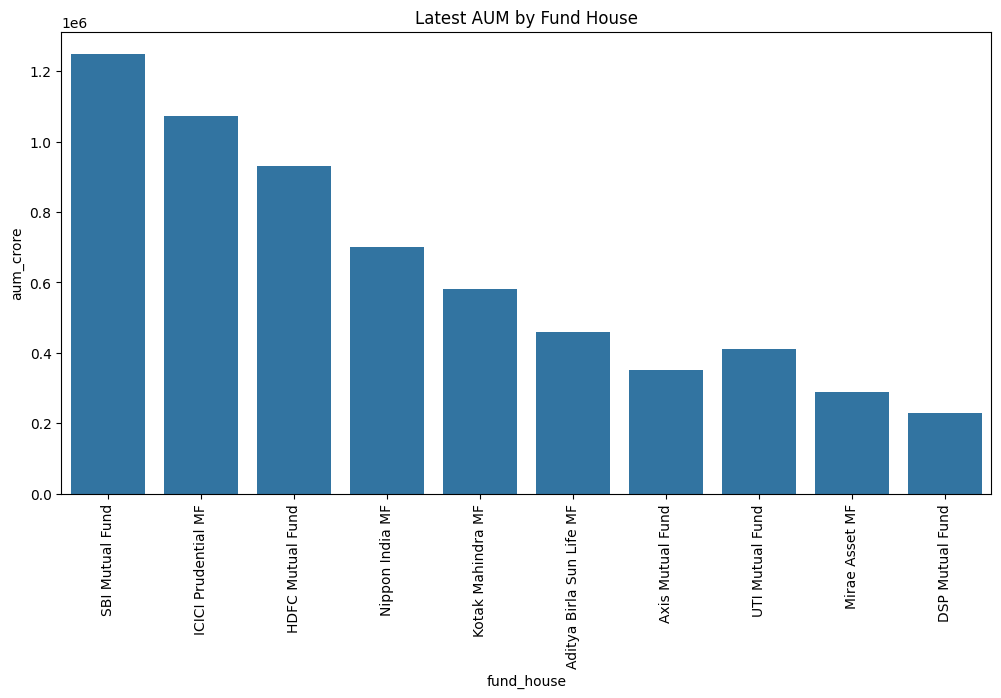

In [4]:
aum_latest = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_latest,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("Latest AUM by Fund House")
plt.show()

In [5]:
## Insight 1: AUM by Fund House

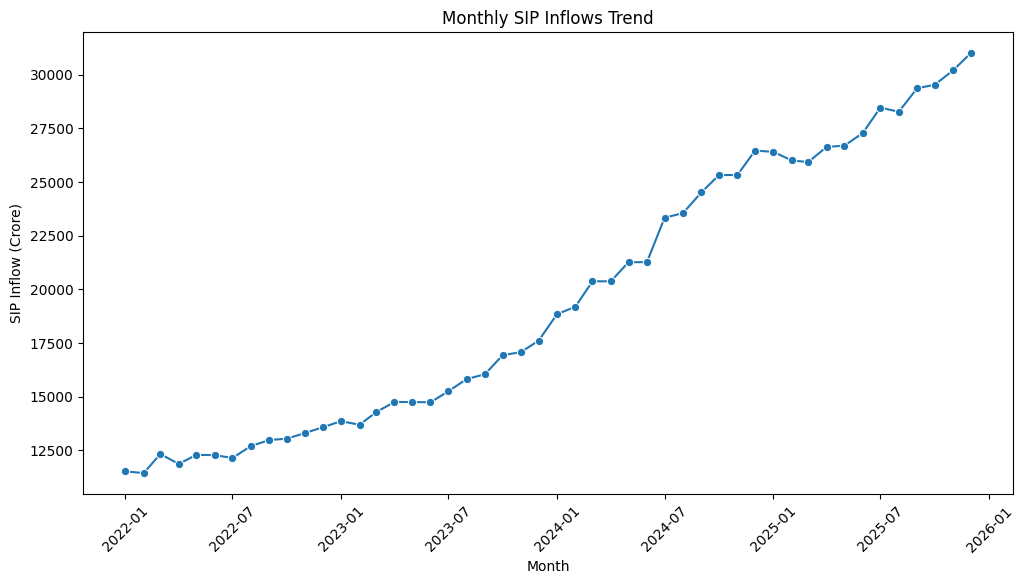

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.title("Monthly SIP Inflows Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)
plt.show()

In [7]:
## Insight 2: SIP Growth Trend

# Observation

    # SIP inflows have shown a strong and consistent upward trend from 2022 to 2025. Monthly inflows increased from around ₹11,500 crore
    # in early 2022 to over ₹31,000 crore by the end of 2025, with only minor short-term fluctuations. The growth accelerated significantly during 2024 and 2025.

# Business Insight

    # The continuous rise in SIP inflows reflects growing retail investor participation, increasing financial awareness, and greater trust in mutual funds 
    # as a long-term wealth creation vehicle. Higher SIP contributions provide fund houses with stable and recurring capital inflows, supporting sustained growth
    # in Assets Under Management (AUM) and indicating a positive outlook for the mutual fund industry.

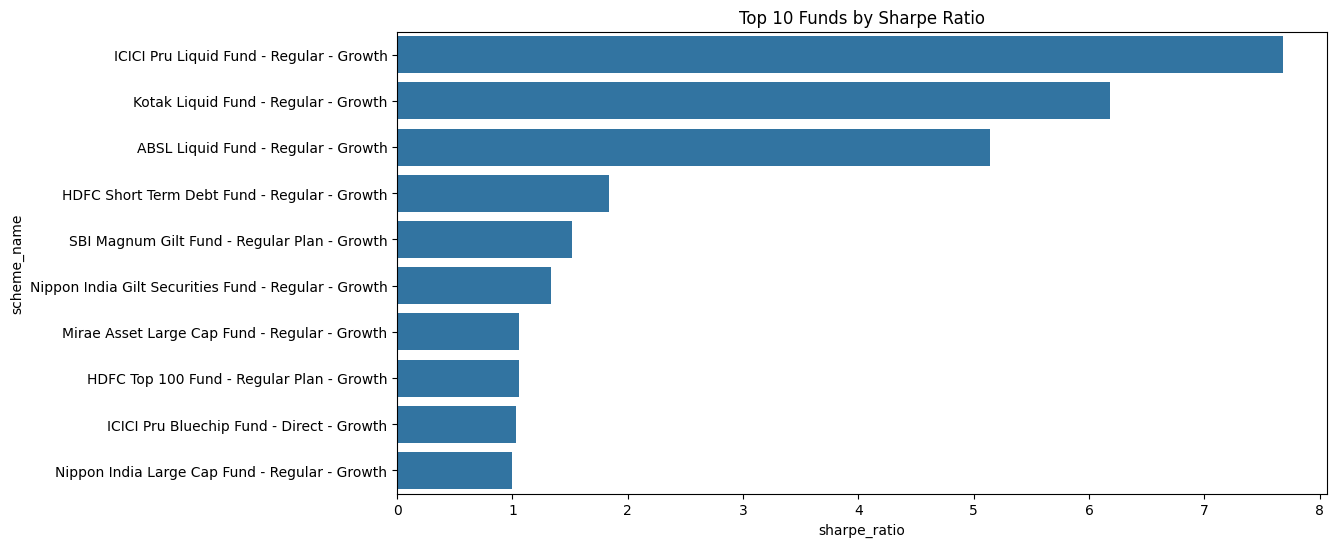

In [8]:
top_sharpe = (
    performance
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

In [9]:
## Insight 3: Risk Adjusted Returns

### Observation
    # Funds with higher Sharpe ratios provide better returns per unit of risk.

### Business Insight
    # Investors seeking efficient risk-adjusted performance may prefer these schemes.

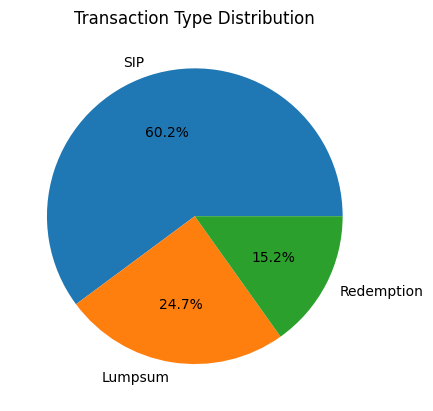

In [10]:
transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Transaction Type Distribution")
plt.show()

In [11]:
## Insight 4: Investor Behaviour

### Observation
# Compare purchase, SIP and redemption proportions.

# ### Business Insight
# A higher share of purchases/SIPs indicates positive market sentiment.

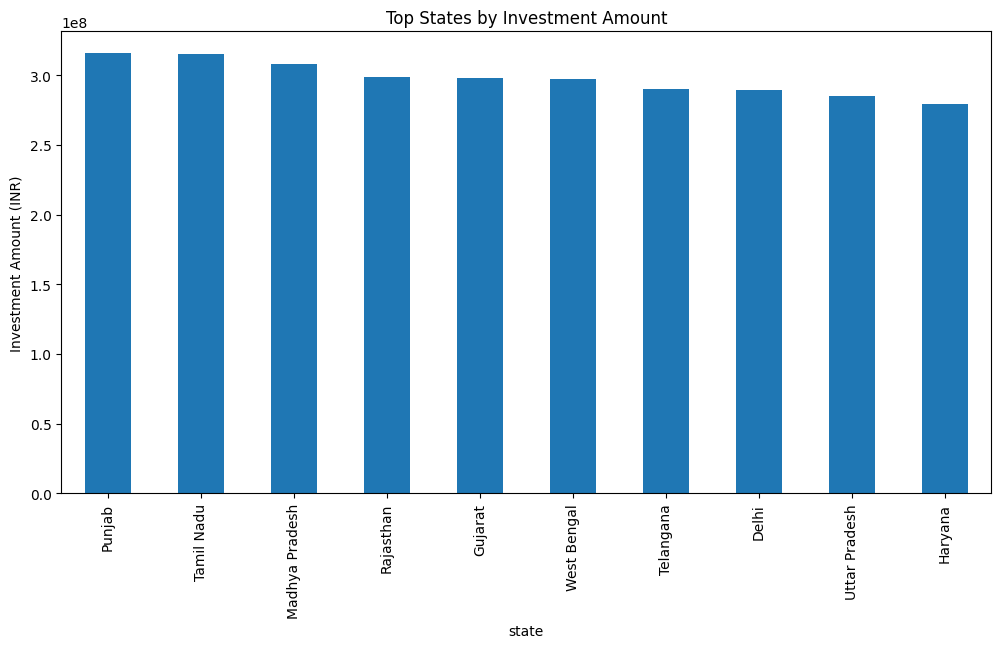

In [12]:
state_amt = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_amt.plot(kind="bar")

plt.title("Top States by Investment Amount")
plt.ylabel("Investment Amount (INR)")
plt.show()

In [13]:
## Insight 5: Geographic Investment Distribution

### Observation
# Identify the top investing states.

# ### Business Insight
# Mutual fund companies can focus marketing and distribution efforts in high-investment regions.

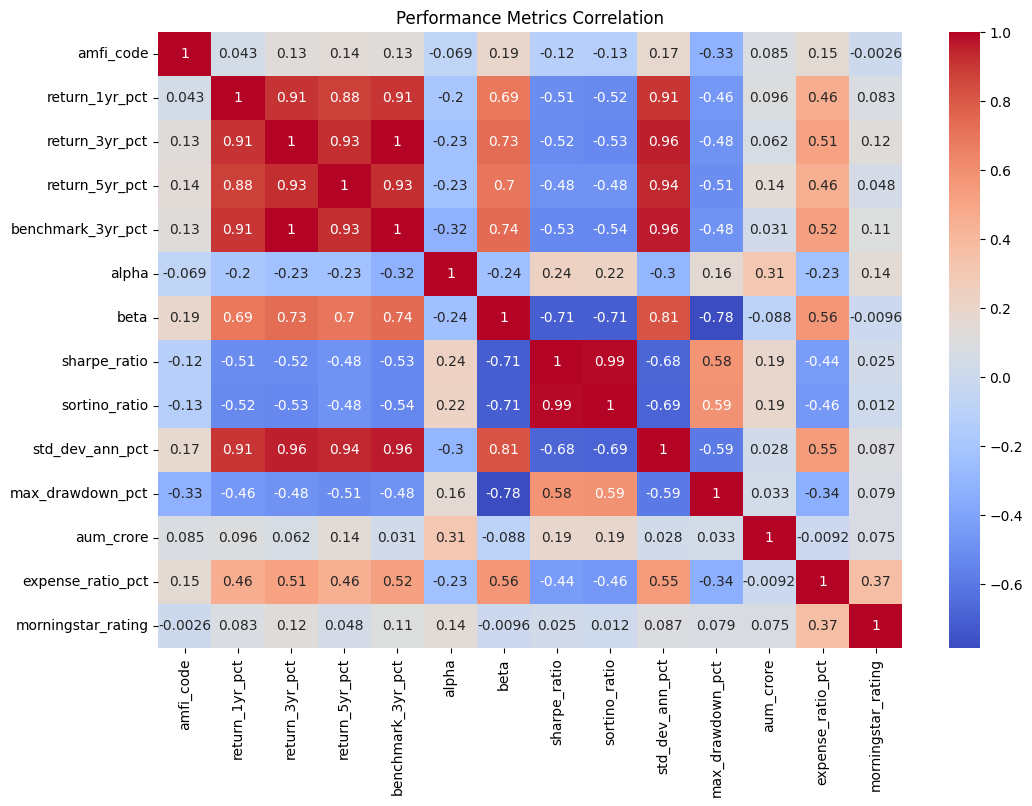

In [14]:
numeric_cols = performance.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Performance Metrics Correlation")
plt.show()

In [15]:
## Insight 6: Correlation Analysis

### Observation
# Identify relationships between returns, Sharpe ratio, alpha, beta and volatility.

# ### Business Insight
# Understanding these relationships helps evaluate risk-return tradeoffs.

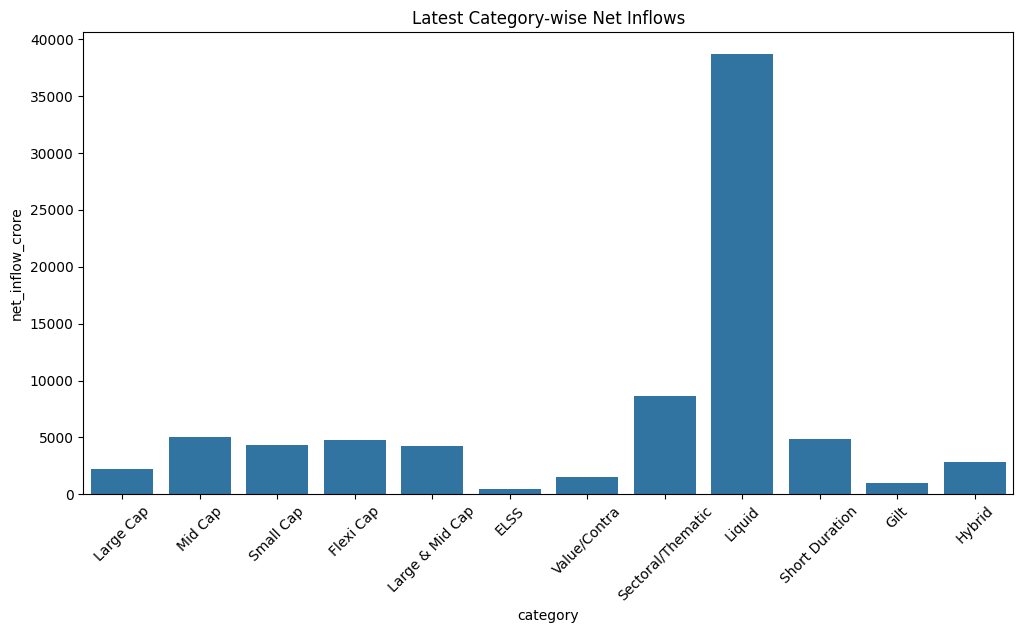

In [16]:
category = pd.read_sql(
    "SELECT * FROM fact_category_inflows",
    conn
)

latest_month = category["month"].max()

latest_category = category[
    category["month"] == latest_month
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_category,
    x="category",
    y="net_inflow_crore"
)

plt.xticks(rotation=45)
plt.title("Latest Category-wise Net Inflows")
plt.show()

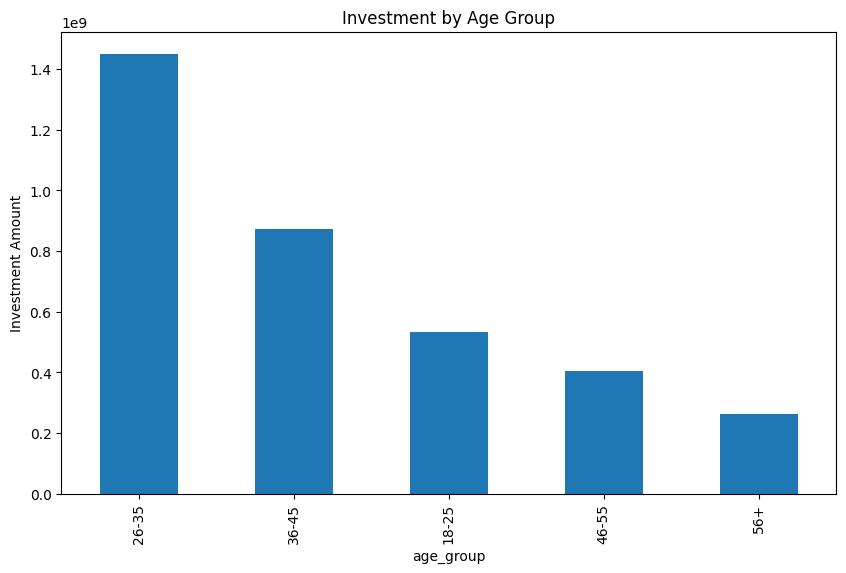

In [17]:
age_data = (
    transactions
    .groupby("age_group")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

age_data.plot(kind="bar")

plt.title("Investment by Age Group")
plt.ylabel("Investment Amount")
plt.show()

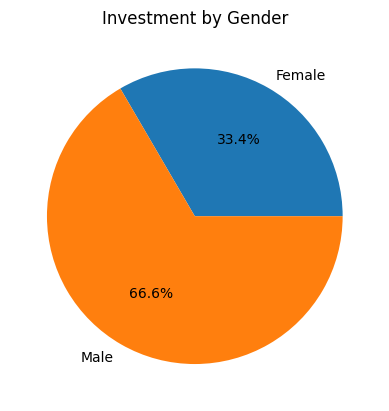

In [18]:
gender_data = (
    transactions
    .groupby("gender")["amount_inr"]
    .sum()
)

gender_data.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investment by Gender")
plt.ylabel("")
plt.show()

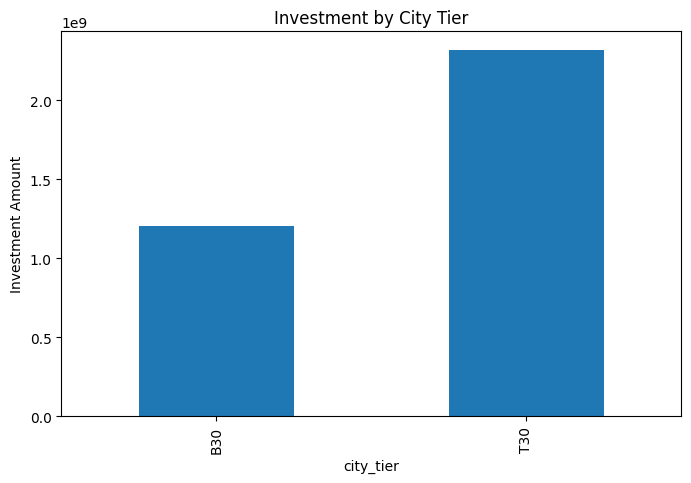

In [19]:
tier_data = (
    transactions
    .groupby("city_tier")["amount_inr"]
    .sum()
)

plt.figure(figsize=(8,5))

tier_data.plot(kind="bar")

plt.title("Investment by City Tier")
plt.ylabel("Investment Amount")
plt.show()

In [20]:
# Key Findings

# 1. Fund house with highest AUM
# 2. Highest Sharpe Ratio fund
# 3. SIP trend over time
# 4. Most active investor age group
# 5. Highest investing state
# 6. Tier-1 vs Tier-2 participation
# 7. Category attracting highest inflows
# 8. Gender participation pattern

In [21]:
nav.head(10000)

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
...,...,...,...
9995,125498,2025-01-20,153.8798
9996,125498,2025-01-21,150.3444
9997,125498,2025-01-22,149.1812
9998,125498,2025-01-23,150.1703


In [22]:
nav['date'] = pd.to_datetime(nav['date'])

In [23]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [24]:
nav['amfi_code'].unique()

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025, 120503, 120504, 120505, 120506, 120507, 118632,
       118633, 118634, 118635, 118636, 120841, 120842, 120843, 120844,
       119092, 119093, 119094, 119095, 101206, 101207, 101208, 102885,
       102886, 102887, 148567, 148568, 148569, 149322, 149323, 149324])

In [25]:
nav=nav.sort_values(by='amfi_code',ascending=True)

In [26]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [28]:
nav.to_csv('clean_nav.csv', index=False)

In [40]:
transactions['transaction_date']=pd.to_datetime(transactions['transaction_date'])

In [41]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [43]:
transactions['transaction_type'].unique()

<ArrowStringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str

In [47]:
transactions=transactions[transactions['amount_inr']>0]

In [51]:
transactions['kyc_status'].unique()

<ArrowStringArray>
['Verified', 'Pending']
Length: 2, dtype: str

In [52]:
transactions.to_csv('clean_transactions.csv',index='False')

In [58]:
performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [61]:
performance[performance['sharpe_ratio']>0]

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low


In [66]:
performance[(performance['expense_ratio_pct']>0.1) & (performance['expense_ratio_pct']<2.5)]

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low


In [ ]:
performance.to_csv('clean_performance.csv'